2026.07.06

비지도 학습

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
x, y = make_blobs(
    n_samples=300,
    centers=3, 
    random_state=42
)

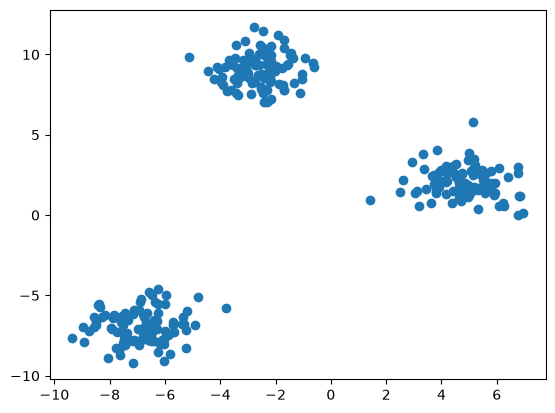

In [3]:
plt.scatter(x[:, 0], x[:, 1])

In [6]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',    # 랜덤하게 만들어지는 중심값을 멀리 떨어뜨려서 만드는 옵션
    random_state=42
)

In [7]:
cluster_labels = kmeans.fit_predict(x)

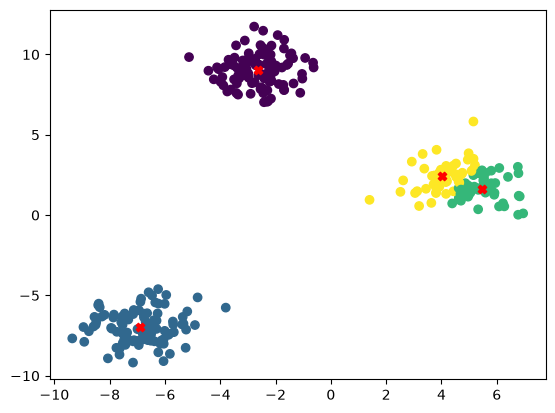

In [12]:
plt.scatter(x[:, 0], x[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X'
)

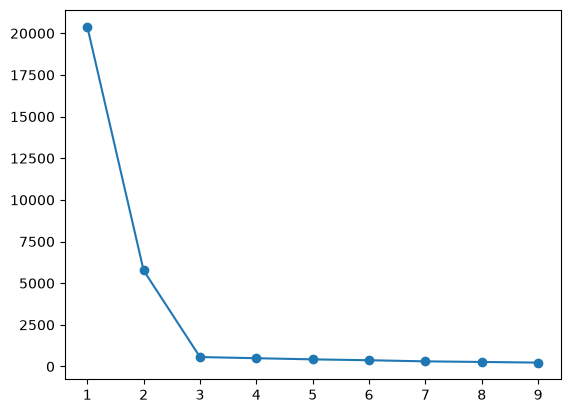

In [15]:
result = []
for k in range(1,10):
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit_predict(x)
    result.append(kmeans_temp.inertia_)

plt.plot(range(1, 10), result, marker='o')

In [16]:
from sklearn.metrics import silhouette_score, silhouette_samples

In [17]:
sil_score = silhouette_score(x, cluster_labels)
print(sil_score)

0.6764211610337508


In [18]:
sil_values = silhouette_samples(x, cluster_labels)
print(sil_values)

[ 0.90388418  0.90065349  0.76177777  0.36624963  0.8502008   0.49691226
  0.86675408  0.43335679  0.86988749  0.84487881  0.8062934   0.42163705
  0.71834536  0.82919497  0.90529356  0.86238879  0.87263445  0.42139498
  0.85237193  0.76800159  0.76307874  0.87314232  0.51083443  0.91162876
  0.86108882  0.84516751  0.88685617  0.35526248  0.26136722  0.83425946
  0.84386061  0.85426021  0.88699182  0.79802712  0.83729144  0.8326916
  0.88829625  0.35571841  0.90140793  0.18329428  0.54452947  0.86188899
  0.90854223  0.32951042  0.81315363  0.81568197  0.91096428  0.36057872
  0.90815911  0.50131096  0.29091106  0.85214974  0.89908137  0.74710787
  0.87339219  0.12442693  0.90689868  0.82093048  0.18164478  0.85113529
  0.88614407  0.41302631  0.39146992  0.69070558  0.88040988  0.49605463
  0.35714521  0.88410536  0.870279    0.8547828   0.49949899  0.84760107
  0.90009386  0.85145116  0.78955765  0.90774412  0.85419446  0.45252523
  0.86555376  0.54700923  0.858755    0.85362918  0.

In [19]:
import numpy as np

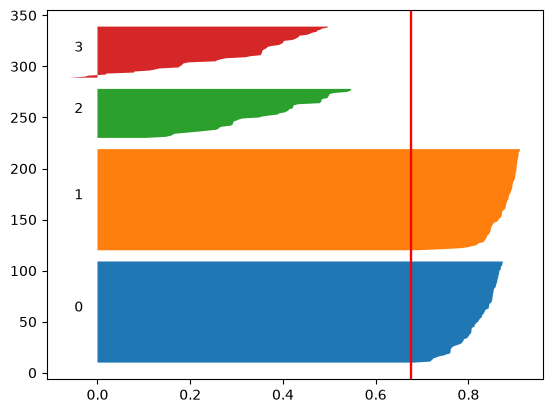

In [20]:
# 시각화준비
y_lower = 10
for i in range(4): # 각 클러스터에대해 반복
    ith_cluster_silhouette_values = sil_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i  # 클러스터별막대 그리기
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)) # 클러스터번호
    y_lower = y_upper + 10 # 다음 클러스터로이동

    plt.axvline(x=sil_score, color='red')

In [21]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [22]:
iris = load_iris() # 데이터셋
X = iris.data   # 특성: 4차원 -> 2차원
y = iris.target # 0, 1, 2

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [33]:
# PCA
pca = PCA(n_components=2)   # 2개의 주성본으로 축소
X_pca = pca.fit_transform(X_scaled)

In [34]:
print(pca.explained_variance_ratio_)

[0.70669709 0.29330291]


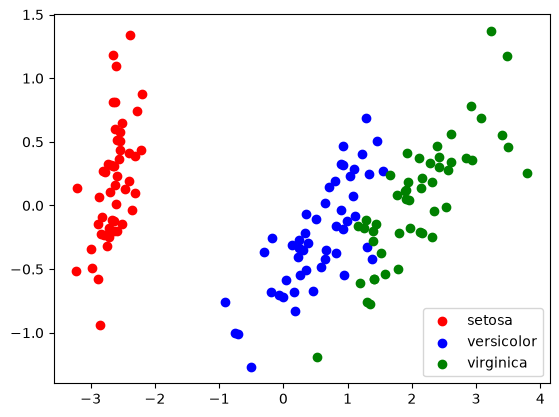

In [37]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()

X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for target, color, label in zip(
    [0, 1, 2],
    ['red', 'blue', 'green'],
    iris.target_names
):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        color=color,
        label=label
    )

plt.legend()
plt.show()

In [38]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [43]:
np.random.seed(42)

nomal_traffic = np.random.normal(loc=50, scale=10, size=(100,2))
#print(nomal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10, 2))
#print(ano_traffic)

# 데이터 병합
traffic_data = np.vstack((nomal_traffic, ano_traffic))
#print(traffic_data)

traffic_df = pd.DataFrame(traffic_data, columns=["Request Time", "Response Time"])



In [45]:
#traffic_data

In [46]:
# 학습 모델 생성
model = IsolationForest(
    n_estimators=100, 
    contamination=0.1,
    random_state=42
)

In [47]:
traffic_df['Anomaly Score'] = model.fit_predict(traffic_data)

In [48]:
traffic_df

,Request Time,Response Time,Anomaly Score
0,54.967142,48.617357,1
1,56.476885,65.230299,1
2,47.658466,47.658630,1
3,65.792128,57.674347,1
4,45.305256,55.425600,1
...,...,...,...
105,125.567120,125.075815,-1
106,139.914759,132.498197,-1
107,135.098344,139.789633,-1
108,144.500267,116.899758,-1


<module 'matplotlib.pyplot' from 'c:\\Users\\EZ\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

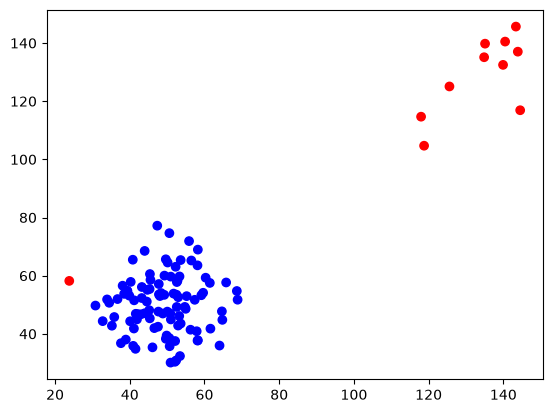

In [52]:
plt.scatter(
    traffic_df["Request Time"], 
    traffic_df["Response Time"],
    c=traffic_df['Anomaly Score'].map({1: "blue", -1: "red"}), # 색상 매핑
    label='Traffic'
)
plt

DBSCAN

In [53]:
from sklearn.cluster import DBSCAN

In [69]:
np.random.seed(42)

nomal_traffic = np.random.normal(loc=50, scale=10, size=(100,2))
#print(nomal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10, 2))
#print(ano_traffic)

# 데이터 병합
traffic_data = np.vstack((nomal_traffic, ano_traffic))
#print(traffic_data)

traffic_df = pd.DataFrame(traffic_data, columns=["Request Time", "Response Time"])



In [70]:
dbscan = DBSCAN(eps=15, min_samples=10)

In [71]:
# 이상치: -1, 나머지: 클러스터 ID
traffic_df['Cluster'] = dbscan.fit_predict(traffic_df)

In [72]:
traffic_df

,Request Time,Response Time,Cluster
0,54.967142,48.617357,0
1,56.476885,65.230299,0
2,47.658466,47.658630,0
3,65.792128,57.674347,0
4,45.305256,55.425600,0
...,...,...,...
105,125.567120,125.075815,-1
106,139.914759,132.498197,-1
107,135.098344,139.789633,-1
108,144.500267,116.899758,-1


In [73]:
traffic_df['Anomaly'] = traffic_df['Cluster'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

In [74]:
traffic_df

,Request Time,Response Time,Cluster,Anomaly
0,54.967142,48.617357,0,Normal
1,56.476885,65.230299,0,Normal
2,47.658466,47.658630,0,Normal
3,65.792128,57.674347,0,Normal
4,45.305256,55.425600,0,Normal
...,...,...,...,...
105,125.567120,125.075815,-1,Anomaly
106,139.914759,132.498197,-1,Anomaly
107,135.098344,139.789633,-1,Anomaly
108,144.500267,116.899758,-1,Anomaly


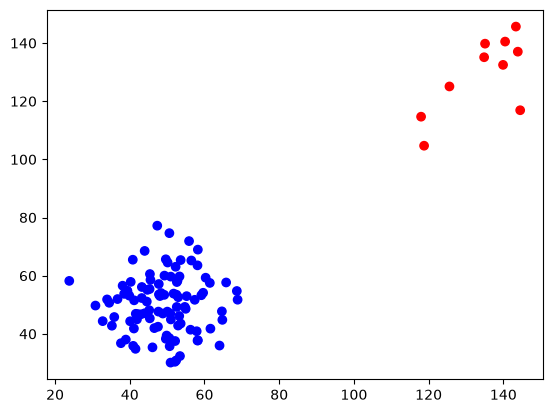

In [75]:
plt.scatter(
    traffic_df['Request Time'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly'].map({"Normal": "blue", "Anomaly": "red"}),
label="Traffic"
)